In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load Data

In [ ]:
df = pd.read_csv("../../data/processed/url_dataset.csv")
df.columns = df.columns.str.lower()

print(f'Data shape (rows,columns): {df.shape}')
print('\n')
print(f'Number of Duplicate rows: {df.duplicated().sum()}')
print("\n")
print(f'Number of missing values: {df.isnull().sum().sum()}')
print("\n")

Data shape (rows,columns): (1353, 10)


Number of Duplicate rows: 629


Number of missing values: 0




In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1353 entries, 0 to 1352
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   sfh                1353 non-null   str  
 1   popupwidnow        1353 non-null   str  
 2   sslfinal_state     1353 non-null   str  
 3   request_url        1353 non-null   str  
 4   url_of_anchor      1353 non-null   str  
 5   web_traffic        1353 non-null   str  
 6   url_length         1353 non-null   str  
 7   age_of_domain      1353 non-null   str  
 8   having_ip_address  1353 non-null   str  
 9   result             1353 non-null   str  
dtypes: str(10)
memory usage: 105.8 KB


## Converting Datatype Object to int64  

In [4]:
import re

def clean_to_int(x):
    if isinstance(x, bytes):
        return int(x.decode())
    if isinstance(x, str):
        # Match negative and positive numbers inside possible b'' or quotes
        match = re.match(r"b?'?\"?(-?\d+)'?\"?", x)
        if match:
            return int(match.group(1))
        # If not matching, try direct conversion
        try:
            return int(x)
        except ValueError:
            return None  # or np.nan if you want to handle missing values
    return int(x)

# Apply cleaning only to columns that should be int
cols = ['sfh', 'popupwidnow', 'sslfinal_state', 'request_url', 'url_of_anchor',
        'web_traffic', 'url_length', 'age_of_domain', 'having_ip_address', 'result']

df[cols] = df[cols].map(clean_to_int)
df = df.astype('int64')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1353 entries, 0 to 1352
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   sfh                1353 non-null   int64
 1   popupwidnow        1353 non-null   int64
 2   sslfinal_state     1353 non-null   int64
 3   request_url        1353 non-null   int64
 4   url_of_anchor      1353 non-null   int64
 5   web_traffic        1353 non-null   int64
 6   url_length         1353 non-null   int64
 7   age_of_domain      1353 non-null   int64
 8   having_ip_address  1353 non-null   int64
 9   result             1353 non-null   int64
dtypes: int64(10)
memory usage: 105.8 KB


In [5]:
df.head()

,sfh,popupwidnow,sslfinal_state,request_url,url_of_anchor,web_traffic,url_length,age_of_domain,having_ip_address,result
0,1,-1,1,-1,-1,1,1,1,0,0
1,-1,-1,-1,-1,-1,0,1,1,1,1
2,1,-1,0,0,-1,0,-1,1,0,1
3,1,0,1,-1,-1,0,1,1,0,0
4,-1,-1,1,-1,0,0,-1,1,0,1


In [6]:
#Basic statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sfh,1353.0,0.237990,0.916389,-1.0,-1.0,1.0,1.0,1.0
popupwidnow,1353.0,-0.258684,0.679072,-1.0,-1.0,0.0,0.0,1.0
sslfinal_state,1353.0,0.327421,0.822193,-1.0,0.0,1.0,1.0,1.0
request_url,1353.0,-0.223208,0.799682,-1.0,-1.0,0.0,0.0,1.0
url_of_anchor,1353.0,-0.025129,0.936262,-1.0,-1.0,0.0,1.0,1.0
web_traffic,1353.0,0.000000,0.806776,-1.0,-1.0,0.0,1.0,1.0
url_length,1353.0,-0.053215,0.762552,-1.0,-1.0,0.0,1.0,1.0
age_of_domain,1353.0,0.219512,0.975970,-1.0,-1.0,1.0,1.0,1.0
having_ip_address,1353.0,0.114560,0.318608,0.0,0.0,0.0,0.0,1.0
result,1353.0,-0.113821,0.954773,-1.0,-1.0,-1.0,1.0,1.0


## Summary Of Numeric Features

In [7]:
def numeric_summary(df):
    obs = df.shape[0]

    numeric_df = df.select_dtypes(include='number')
    summary_df = pd.DataFrame(
        {
            'Dtype': numeric_df.dtypes,
            'Counts': numeric_df.apply(lambda x: x.count()),
            'NUlls': numeric_df.apply(lambda x: x.isnull().sum()),
            'NullPercent': (numeric_df.isnull().sum() / obs) * 100,
            "Min": numeric_df.min(),
            'Max': numeric_df.max(),
            'Uniques': numeric_df.apply(lambda x: x.unique().shape[0]),
            'UniqueValues': numeric_df.apply(lambda x: list(x.unique()) if x.nunique() <= 10 else '-')
        }
    )

    print('___________________________\nData Types:')
    print(summary_df['Dtype'].value_counts())
    print('___________________________')
    print('Numreical Features Summary:')

    return summary_df

numeric_summary(df)


___________________________
Data Types:
Dtype
int64    10
Name: count, dtype: int64
___________________________
Numreical Features Summary:


,Dtype,Counts,NUlls,NullPercent,Min,Max,Uniques,UniqueValues
sfh,int64,1353,0,0.0,-1,1,3,"[1, -1, 0]"
popupwidnow,int64,1353,0,0.0,-1,1,3,"[-1, 0, 1]"
sslfinal_state,int64,1353,0,0.0,-1,1,3,"[1, -1, 0]"
request_url,int64,1353,0,0.0,-1,1,3,"[-1, 0, 1]"
url_of_anchor,int64,1353,0,0.0,-1,1,3,"[-1, 0, 1]"
web_traffic,int64,1353,0,0.0,-1,1,3,"[1, 0, -1]"
url_length,int64,1353,0,0.0,-1,1,3,"[1, -1, 0]"
age_of_domain,int64,1353,0,0.0,-1,1,2,"[1, -1]"
having_ip_address,int64,1353,0,0.0,0,1,2,"[0, 1]"
result,int64,1353,0,0.0,-1,1,3,"[0, 1, -1]"


## Important Note
- There are no missing and duplicate values.
- 'age_of_domain' [1,-1] and 'having_ip_address' [0,1] columns have two unique values.

## User Defined function for counting and percentange

In [8]:
# User defined fonction for counting and percentage values in the each column
def get_value_count(df, column_name):
    vc = df[column_name].value_counts()
    vc_norm = df[column_name].value_counts(normalize=True)

    vc = vc.rename_axis(column_name).reset_index(name='counts')
    vc_norm = vc_norm.rename_axis(column_name).reset_index(name='percent')
    
    df_result = pd.concat([vc[column_name], vc['counts'],vc_norm['percent']],axis=1)
    
    return df_result

## Target Feature: Result Total Probability
- 1:Legitimate
- 0:suspicious
- -1:phihing

In [9]:
# Total Number of values and percentage 
get_value_count(df, 'result')

,result,counts,percent
0,-1,702,0.518847
1,1,548,0.405026
2,0,103,0.076127


## Represet as grapgh from dataset

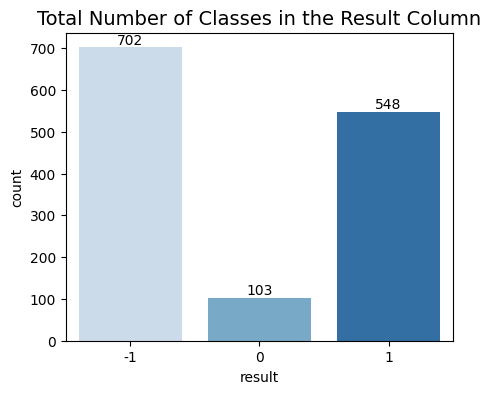

In [11]:
plt.figure(figsize=(5,4))
ax = sns.countplot(data=df,x='result', palette='Blues')

ax.bar_label(ax.containers[0]) # type: ignore
ax.set_title("Total Number of Classes in the Result Column",size=14)
plt.show()

## Correlations

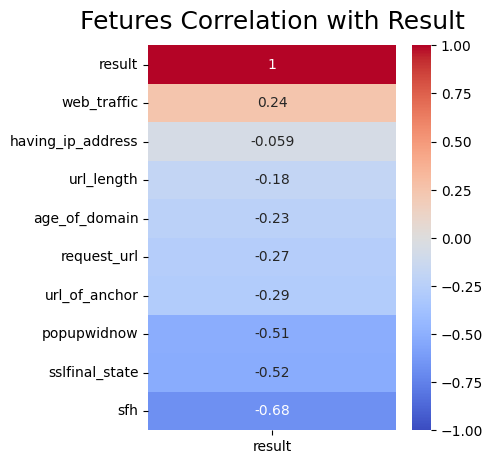

In [12]:
plt.figure(figsize=(4,5))
heatmap = sns.heatmap(df.corr()[['result']].sort_values(by='result', ascending=False), vmin=-1, vmax=1, annot=True, cmap = 'coolwarm')
heatmap.set_title('Fetures Correlation with Result', fontdict={'fontsize':18}, pad=12);
# plt.show()
plt.savefig('heatmapfeaturecorr.png', dpi=300, bbox_inches='tight')